<h2>Can we identify whether a token in code is an iterator binder from the hidden states of a coding LLM</h2>

A token-level probing framework in which linear classifiers are trained on hidden-state representations from coding LLMs to predict whether individual variable tokens belong to a specific functional role, beginning with iterator variables.

- Language: Python
- Role: Iterator Binder only
- Model: Qwen2.5-Coder-1.5B
- Labels: Binary {1: iterator binder token, 0: everything else}

A. Role identification:
Can the model represent that a token is the iterator variable inside the for loop

B. Variables tracking:
Can the model then connect later uses of that variable back to the binder

In [1]:
import sys, platform
print("python:", sys.executable)
print("machine:", platform.machine())

python: /Users/arkdutt/Desktop/Algoverse/mechinterp_venv/bin/python
machine: arm64


In [2]:
import torch, transformers, tokenizers, huggingface_hub

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("hub:", huggingface_hub.__version__)
print("mps available:", torch.backends.mps.is_available())

/Users/arkdutt/Desktop/Algoverse/mechinterp_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.10.0
transformers: 5.3.0
tokenizers: 0.22.2
hub: 1.7.1
mps available: True


In [3]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-Coder-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer.tokenize("for i in range(3):\n    print(i)"))

['for', 'Ġi', 'Ġin', 'Ġrange', '(', '3', '):Ċ', 'ĠĠĠ', 'Ġprint', '(i', ')']


In [4]:
from transformers import AutoModelForCausalLM
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32
).to(device)

print("model loaded")

device: mps


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:06<00:00, 51.52it/s]


model loaded


Example Code Snippet:

```
    for i in range(3):
        print(i)
```

We want to turn this coding snippet to a tokenized version of the code and run a classifier that learns iterator binder or not.

The Pipeline:
```
Load the modal -> load the code -> detect iterator binder (Python AST) -> tokenize the code -> 
```

In [5]:
code = "for i in range(3):\n    print(i)"

In [6]:
out = tokenizer(code, return_offsets_mapping=True, add_special_tokens=False)

for tok_id, offset in zip(out["input_ids"], out["offset_mapping"]):
    tok = tokenizer.decode([tok_id])
    print(f"{repr(tok):15} {offset}")

'for'           (0, 3)
' i'            (3, 5)
' in'           (5, 8)
' range'        (8, 14)
'('             (14, 15)
'3'             (15, 16)
'):\n'          (16, 19)
'   '           (19, 22)
' print'        (22, 28)
'(i'            (28, 30)
')'             (30, 31)


Tokenizer: turns code into the exact token sequence the model sees. Defines the units the probe will operate on.
The model then produces hidden states for each token.

The whole essence of probing is to take the hidden states and ask whether they encode iterator=role info.

In [7]:
import ast

# AST stores positions as (line, col) pairs
# Tokenizer gives token positions as character offsets
# So, we convert AST positions into char offsets
def line_col_to_char_offset(code, line, col):
    lines = code.splitlines(keepends=True)
    return sum(len(lines[i]) for i in range(line - 1)) + col

# spans are character positions in the string -> (start_idx, end_idx)
def find_iterator_spans(code):
    tree = ast.parse(code) # converts the python code to python ast
    spans = []

    for node in ast.walk(tree):
        if isinstance(node, ast.For): # does the code have a 'for loop'
            target = node.target
            start = line_col_to_char_offset(code, target.lineno, target.col_offset)
            end = line_col_to_char_offset(code, target.end_lineno, target.end_col_offset)
            spans.append((start, end))

    return spans

In [8]:
spans = find_iterator_spans(code)
print(spans)

for s, e in spans:
    print("iterator text:", repr(code[s:e]))

[(4, 5)]
iterator text: 'i'


In [9]:
# return true if two half-open character intervals overlap
# [4,6) and [4,5) -> overlap = True
# this helps us decide whether a token should be labeled as an iterator token
def overlaps(a_start, a_end, b_start, b_end):
    return max(a_start, b_start) < min(a_end, b_end)

# convert the iterator spans into token-level binary label
# {1: if the token overlaps any iterator binder span, 0: otherwise}
def align_spans_to_tokens(spans, offset_mapping):
    labels = []
    for start, end in offset_mapping:
        label = 0
        for s, e in spans:
            if overlaps(start, end, s, e):
                label = 1
                break
        labels.append(label)
    return labels

In [10]:
labels = align_spans_to_tokens(spans, out["offset_mapping"])

for tok_id, offset, label in zip(out["input_ids"], out["offset_mapping"], labels):
    tok = tokenizer.decode([tok_id])
    print(f"{repr(tok):15} {offset}  label={label}")

'for'           (0, 3)  label=0
' i'            (3, 5)  label=1
' in'           (5, 8)  label=0
' range'        (8, 14)  label=0
'('             (14, 15)  label=0
'3'             (15, 16)  label=0
'):\n'          (16, 19)  label=0
'   '           (19, 22)  label=0
' print'        (22, 28)  label=0
'(i'            (28, 30)  label=0
')'             (30, 31)  label=0


In [11]:
inputs = tokenizer(code, return_tensors="pt", add_special_tokens=False).to(device)

with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

print(len(outputs.hidden_states))
print(outputs.hidden_states[-1].shape)

29
torch.Size([1, 11, 1536])


<h3>How do we know that the `i` in the body is the same `i` from the header</h3>

- Find all token names named `i` = WRONG
- Find all AST nodes that refer to the same binding of `i` = CORRECT

In [12]:
# recursively extract variable names from a loop target
def extract_target_names(target):
    names = set()

    if isinstance(target, ast.Name):
        names.add(target.id)

    elif isinstance(target, (ast.Tuple, ast.List)):
        for elt in target.elts:
            names.update(extract_target_names(elt))

    return names

In [13]:
# converts the ast node into character span (start, end)
def node_to_span(code, node):
    start = line_col_to_char_offset(code, node.lineno, node.col_offset)
    end = line_col_to_char_offset(code, node.end_lineno, node.end_col_offset)
    return (start, end)

In [14]:
def find_iterator_and_body_use_spans(code):
    """
    Return spans for:
      1. iterator binders in the for-loop header
      2. matching uses of those iterator variables inside the loop body

    Important:
    - We include uses recursively inside the loop body.
    - We avoid counting uses that belong to an inner loop that rebinds the same variable.
    """
    tree = ast.parse(code)
    spans = []

    def visit_for_node(for_node):
        
        # 1: get iterator variable names from the loop header
        iterator_names = extract_target_names(for_node.target)

        # 2: add span(s) for the header binder itself
        def add_target_spans(target):
            if isinstance(target, ast.Name):
                spans.append(node_to_span(code, target))
            elif isinstance(target, (ast.Tuple, ast.List)):
                for elt in target.elts:
                    add_target_spans(elt)

        add_target_spans(for_node.target)

        # 3: walk the loop body and collect matching variable uses
        def collect_uses(node, blocked_names=None):
            """
            blocked_names = names that have been shadowed by an inner loop target
            """
            if blocked_names is None:
                blocked_names = set()

            # If we hit a nested for-loop, it may shadow some iterator names
            if isinstance(node, ast.For):
                inner_bound = extract_target_names(node.target)

                # First, collect inside the nested loop target itself if needed
                # but do NOT treat nested target binders as uses of the outer loop
                # So we skip adding anything here.

                # Recurse into the nested body, but mark shadowed names as blocked
                new_blocked = blocked_names | (inner_bound & iterator_names)

                for child in node.body:
                    collect_uses(child, new_blocked)

                for child in node.orelse:
                    collect_uses(child, new_blocked)

                return

            # Count variable uses that match the iterator names and are not shadowed
            if isinstance(node, ast.Name):
                if (
                    node.id in iterator_names
                    and node.id not in blocked_names
                    and isinstance(node.ctx, ast.Load)
                ):
                    spans.append(node_to_span(code, node))

            # Recurse normally
            for child in ast.iter_child_nodes(node):
                collect_uses(child, blocked_names)

        for stmt in for_node.body:
            collect_uses(stmt)

        for stmt in for_node.orelse:
            collect_uses(stmt)

    # Find all top-level and nested for-loops
    for node in ast.walk(tree):
        if isinstance(node, ast.For):
            visit_for_node(node)

    return spans

In [15]:
code = """for i in range(3):
    j = i
    for i in range(2):
        print(i)
"""

spans = find_iterator_and_body_use_spans(code)
print("spans:", spans)

for s, e in spans:
    print(repr(code[s:e]))

spans: [(4, 5), (27, 28), (37, 38), (66, 67)]
'i'
'i'
'i'
'i'


<h1>Loading XLCoST Program-Level Data</h1>

In [120]:
import json
import ast
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/Ark Algoverse/data/XLCoST_data/retrieval/code2code_search/program_level"

def xlcost_tokens_to_code(tokens):
    lines, current, indent = [], [], 0
    def flush():
        nonlocal current
        if current:
            lines.append(('    ' * indent) + ' '.join(current).strip())
            current.clear()
    for tok in tokens:
        if tok == 'NEW_LINE': flush()
        elif tok == 'INDENT': flush(); indent += 1
        elif tok == 'DEDENT': flush(); indent = max(0, indent - 1)
        elif tok == 'STRNEWLINE': current.append('\\n')
        else: current.append(tok)
    flush()
    return '\n'.join(lines).strip()

def load_xlcost(language, split='train', limit=None):
    path = f"{DATA_DIR}/{language}/{split}.jsonl"
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            rec = json.loads(line)
            code = xlcost_tokens_to_code(rec['docstring_tokens'])
            try:
                ast.parse(code)
                rows.append({'code': code, 'language': language, 'split': split})
            except Exception:
                continue
    return pd.DataFrame(rows)

df = load_xlcost('Python', split='train', limit=3000)
print(f"Loaded {len(df)} valid Python programs from XLCoST program-level")
print(df.head())


num snippets: 700
                                                code
0  stash_snarky_cactus_239 = 0\nbump_spicy_widget...
1  box_goofy_turnip_585 = []\nshift_noisy_lizard_...
2  memo_snarky_otter_231 = {'even': 0, 'odd': 0}\...
3  chop_snarky_badger_758 = 'abcdefg'\nout_lurid_...
4  total_quirky_goblin_92 = 0\nfor orbit_goofy_bu...


In [121]:
for i in range(10):
    code = df.loc[i, "code"]
    print(f"\n===== snippet {i} =====")
    print(code)

    try:
        spans = find_iterator_and_body_use_spans(code)
        print("spans:", spans)

        for s, e in spans:
            print("matched text:", repr(code[s:e]))

    except Exception as e:
        print("ERROR:", e)


===== snippet 0 =====
stash_snarky_cactus_239 = 0
bump_spicy_widget_703 = 3
for iter_brutal_turnip_770 in range(4, 20, 1):
    stash_snarky_cactus_239 += iter_brutal_turnip_770 + bump_spicy_widget_703
print(stash_snarky_cactus_239)
spans: [(58, 80), (132, 154)]
matched text: 'iter_brutal_turnip_770'
matched text: 'iter_brutal_turnip_770'

===== snippet 1 =====
box_goofy_turnip_585 = []
shift_noisy_lizard_440 = 2
for loop_noisy_cactus_528 in range(14):
    box_goofy_turnip_585.append((loop_noisy_cactus_528 + shift_noisy_lizard_440) * 2)
print(box_goofy_turnip_585)
spans: [(57, 78), (126, 147)]
matched text: 'loop_noisy_cactus_528'
matched text: 'loop_noisy_cactus_528'

===== snippet 2 =====
memo_snarky_otter_231 = {'even': 0, 'odd': 0}
for walker_grimy_pigeon_359 in range(2, 8, 1):
    if walker_grimy_pigeon_359 % 2 == 0:
        memo_snarky_otter_231['even'] += 1
    else:
        memo_snarky_otter_231['odd'] += 1
print(memo_snarky_otter_231)
spans: [(50, 73), (100, 123)]
matched text

In [122]:
for i in range(5):
    code = df.loc[i, "code"]
    print(f"\n===== snippet {i} =====")
    print(code)

    try:
        spans = find_iterator_and_body_use_spans(code)
        out = tokenizer(code, return_offsets_mapping=True, add_special_tokens=False)
        labels = align_spans_to_tokens(spans, out["offset_mapping"])

        for tok_id, offset, label in zip(out["input_ids"], out["offset_mapping"], labels):
            tok = tokenizer.decode([tok_id])
            print(f"{repr(tok):20} {offset}  label={label}")

    except Exception as e:
        print("ERROR:", e)


===== snippet 0 =====
stash_snarky_cactus_239 = 0
bump_spicy_widget_703 = 3
for iter_brutal_turnip_770 in range(4, 20, 1):
    stash_snarky_cactus_239 += iter_brutal_turnip_770 + bump_spicy_widget_703
print(stash_snarky_cactus_239)
'stash'              (0, 5)  label=0
'_sn'                (5, 8)  label=0
'ark'                (8, 11)  label=0
'y'                  (11, 12)  label=0
'_c'                 (12, 14)  label=0
'actus'              (14, 19)  label=0
'_'                  (19, 20)  label=0
'2'                  (20, 21)  label=0
'3'                  (21, 22)  label=0
'9'                  (22, 23)  label=0
' ='                 (23, 25)  label=0
' '                  (25, 26)  label=0
'0'                  (26, 27)  label=0
'\n'                 (27, 28)  label=0
'b'                  (28, 29)  label=0
'ump'                (29, 32)  label=0
'_sp'                (32, 35)  label=0
'icy'                (35, 38)  label=0
'_widget'            (38, 45)  label=0
'_'                  (45, 46)  

In [123]:
results = []

for idx, code in enumerate(df["code"]):
    try:
        spans = find_iterator_and_body_use_spans(code)
        out = tokenizer(code, return_offsets_mapping=True, add_special_tokens=False)
        labels = align_spans_to_tokens(spans, out["offset_mapping"])

        results.append({
            "row": idx,
            "parsed_ok": True,
            "num_spans": len(spans),
            "num_positive_tokens": sum(labels),
            "num_tokens": len(labels),
            "code": code
        })

    except Exception as e:
        results.append({
            "row": idx,
            "parsed_ok": False,
            "num_spans": None,
            "num_positive_tokens": None,
            "num_tokens": None,
            "error": str(e),
            "code": code
        })

results_df = pd.DataFrame(results)
results_df.head()

,row,parsed_ok,num_spans,num_positive_tokens,num_tokens,code
0,0,True,2,20,95,stash_snarky_cactus_239 = 0\nbump_spicy_widget...
1,1,True,2,18,90,box_goofy_turnip_585 = []\nshift_noisy_lizard_...
2,2,True,2,22,118,"memo_snarky_otter_231 = {'even': 0, 'odd': 0}\..."
3,3,True,2,17,106,chop_snarky_badger_758 = 'abcdefg'\nout_lurid_...
4,4,True,4,32,82,total_quirky_goblin_92 = 0\nfor orbit_goofy_bu...


**Training the probe**

In [124]:
import torch

def build_token_level_data_for_snippet(code, layer_idx):
    """
    For one code snippet, return:
      X: hidden states for each token at one layer  -> shape [num_tokens, hidden_dim]
      y: token labels (1 if iterator binder/body use, else 0) -> shape [num_tokens]
      tokens: decoded token strings
      offsets: character offsets for each token
    """
    # Ground-truth spans from AST: binder + matching body uses
    spans = find_iterator_and_body_use_spans(code)

    # Tokenization for labels
    tok = tokenizer(
        code,
        return_offsets_mapping=True,
        add_special_tokens=False
    )

    labels = align_spans_to_tokens(spans, tok["offset_mapping"])

    # Tokenization for model forward pass
    inputs = tokenizer(
        code,
        return_tensors="pt",
        add_special_tokens=False
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Hidden states for the chosen layer
    # shape: [1, seq_len, hidden_dim] -> [seq_len, hidden_dim]
    hidden = outputs.hidden_states[layer_idx][0].detach().cpu()

    y = torch.tensor(labels, dtype=torch.long)

    # Decode tokens for debugging / inspection
    tokens = [tokenizer.decode([tok_id]) for tok_id in tok["input_ids"]]
    offsets = tok["offset_mapping"]

    # Safety check
    assert hidden.shape[0] == len(y), (
        f"Mismatch: hidden has {hidden.shape[0]} tokens, labels has {len(y)}"
    )

    return hidden, y, tokens, offsets

In [125]:
test_code = df.loc[0, "code"]

X_one, y_one, toks_one, offs_one = build_token_level_data_for_snippet(
    test_code,
    layer_idx=8
)

print("X shape:", X_one.shape)
print("y shape:", y_one.shape)

for tok, off, label in zip(toks_one, offs_one, y_one.tolist()):
    print(f"{repr(tok):20} {off}  label={label}")

X shape: torch.Size([95, 1536])
y shape: torch.Size([95])
'stash'              (0, 5)  label=0
'_sn'                (5, 8)  label=0
'ark'                (8, 11)  label=0
'y'                  (11, 12)  label=0
'_c'                 (12, 14)  label=0
'actus'              (14, 19)  label=0
'_'                  (19, 20)  label=0
'2'                  (20, 21)  label=0
'3'                  (21, 22)  label=0
'9'                  (22, 23)  label=0
' ='                 (23, 25)  label=0
' '                  (25, 26)  label=0
'0'                  (26, 27)  label=0
'\n'                 (27, 28)  label=0
'b'                  (28, 29)  label=0
'ump'                (29, 32)  label=0
'_sp'                (32, 35)  label=0
'icy'                (35, 38)  label=0
'_widget'            (38, 45)  label=0
'_'                  (45, 46)  label=0
'7'                  (46, 47)  label=0
'0'                  (47, 48)  label=0
'3'                  (48, 49)  label=0
' ='                 (49, 51)  label=0
' '        

In [126]:
from sklearn.model_selection import train_test_split

snippet_indices = list(range(len(df)))

train_idx, test_idx = train_test_split(
    snippet_indices,
    test_size=0.2,
    random_state=42
)

print("train snippets:", len(train_idx))
print("test snippets :", len(test_idx))

train snippets: 560
test snippets : 140


In [127]:
import numpy as np

def collect_dataset(df, snippet_indices, layer_idx, print_every=10, max_snippets=None):
    X_list = []
    y_list = []
    skipped = 0
    kept = 0

    if max_snippets is not None:
        snippet_indices = snippet_indices[:max_snippets]

    total = len(snippet_indices)

    for j, idx in enumerate(snippet_indices):
        if j % print_every == 0:
            print(f"[layer {layer_idx}] processing {j}/{total}")

        code = df.loc[idx, "code"]

        try:
            X_snip, y_snip, _, _ = build_token_level_data_for_snippet(
                code,
                layer_idx=layer_idx
            )

            # skip snippets with no positive labels
            if y_snip.sum().item() == 0:
                skipped += 1
                continue

            X_list.append(X_snip.numpy())
            y_list.append(y_snip.numpy())
            kept += 1

        except Exception as e:
            skipped += 1
            print(f"Skipping snippet {idx} because of error: {e}")

    if len(X_list) == 0:
        raise ValueError("No valid snippets were collected.")

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    print("Kept snippets   :", kept)
    print("Skipped snippets:", skipped)
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Positive labels:", y.sum())
    print("Total labels   :", len(y))
    print("Positive rate  :", y.mean())

    return X, y

In [128]:
layer_idx = 8  # change if needed

X_train, y_train = collect_dataset(df, train_idx, layer_idx=layer_idx)
X_test, y_test = collect_dataset(df, test_idx, layer_idx=layer_idx)

[layer 8] processing 0/560
[layer 8] processing 10/560
[layer 8] processing 20/560
[layer 8] processing 30/560
[layer 8] processing 40/560
[layer 8] processing 50/560
[layer 8] processing 60/560
[layer 8] processing 70/560
[layer 8] processing 80/560
[layer 8] processing 90/560
[layer 8] processing 100/560
[layer 8] processing 110/560
[layer 8] processing 120/560
[layer 8] processing 130/560
[layer 8] processing 140/560
[layer 8] processing 150/560
[layer 8] processing 160/560
[layer 8] processing 170/560
[layer 8] processing 180/560
[layer 8] processing 190/560
[layer 8] processing 200/560
[layer 8] processing 210/560
[layer 8] processing 220/560
[layer 8] processing 230/560
[layer 8] processing 240/560
[layer 8] processing 250/560
[layer 8] processing 260/560
[layer 8] processing 270/560
[layer 8] processing 280/560
[layer 8] processing 290/560
[layer 8] processing 300/560
[layer 8] processing 310/560
[layer 8] processing 320/560
[layer 8] processing 330/560
[layer 8] processing 340/

In [129]:
from sklearn.linear_model import LogisticRegression

probe = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

probe.fit(X_train, y_train)
print("Probe trained.")

Probe trained.


In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = probe.predict(X_test)

print("accuracy :", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, zero_division=0))
print("recall   :", recall_score(y_test, y_pred, zero_division=0))
print("f1       :", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy : 0.9984930474690047
precision: 0.9941747572815534
recall   : 0.999721059972106
f1       : 0.9969401947148818

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11014
           1       0.99      1.00      1.00      3585

    accuracy                           1.00     14599
   macro avg       1.00      1.00      1.00     14599
weighted avg       1.00      1.00      1.00     14599



In [131]:
baseline_pred = np.zeros_like(y_test)

print("baseline accuracy :", accuracy_score(y_test, baseline_pred))
print("baseline precision:", precision_score(y_test, baseline_pred, zero_division=0))
print("baseline recall   :", recall_score(y_test, baseline_pred, zero_division=0))
print("baseline f1       :", f1_score(y_test, baseline_pred, zero_division=0))

baseline accuracy : 0.7544352352900884
baseline precision: 0.0
baseline recall   : 0.0
baseline f1       : 0.0


In [132]:
snippet_positive_counts = []

for idx in range(len(df)):
    code = df.loc[idx, "code"]
    try:
        spans = find_iterator_and_body_use_spans(code)
        tok = tokenizer(code, return_offsets_mapping=True, add_special_tokens=False)
        labels = align_spans_to_tokens(spans, tok["offset_mapping"])
        snippet_positive_counts.append(sum(labels))
    except Exception as e:
        snippet_positive_counts.append(None)
        print(f"Snippet {idx} failed: {e}")

valid_counts = [x for x in snippet_positive_counts if x is not None]
print("num valid snippets:", len(valid_counts))
print("snippets with zero positives:", sum(x == 0 for x in valid_counts))
print("avg positive tokens per valid snippet:", np.mean(valid_counts))

num valid snippets: 700
snippets with zero positives: 0
avg positive tokens per valid snippet: 26.46142857142857


In [134]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Number of hidden-state layers returned by the model
sample_inputs = tokenizer("for i in range(3): print(i)", return_tensors="pt", add_special_tokens=False).to(device)
with torch.no_grad():
    sample_outputs = model(**sample_inputs, output_hidden_states=True)

num_layers = len(sample_outputs.hidden_states)
print("Number of hidden-state layers:", num_layers)

layer_results = []

for layer_idx in range(num_layers):
    print(f"\n=== Layer {layer_idx} ===")

    X_train, y_train = collect_dataset(df, train_idx, layer_idx=layer_idx)
    X_test, y_test = collect_dataset(df, test_idx, layer_idx=layer_idx)

    probe = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
    probe.fit(X_train, y_train)
    y_pred = probe.predict(X_test)

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"precision={prec:.4f}, recall={rec:.4f}, f1={f1:.4f}")

    layer_results.append({
        "layer": layer_idx,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

results_df = pd.DataFrame(layer_results)
results_df

Number of hidden-state layers: 29

=== Layer 0 ===
[layer 0] processing 0/560
[layer 0] processing 10/560
[layer 0] processing 20/560
[layer 0] processing 30/560
[layer 0] processing 40/560
[layer 0] processing 50/560
[layer 0] processing 60/560
[layer 0] processing 70/560
[layer 0] processing 80/560
[layer 0] processing 90/560
[layer 0] processing 100/560
[layer 0] processing 110/560
[layer 0] processing 120/560
[layer 0] processing 130/560
[layer 0] processing 140/560
[layer 0] processing 150/560
[layer 0] processing 160/560
[layer 0] processing 170/560
[layer 0] processing 180/560
[layer 0] processing 190/560
[layer 0] processing 200/560
[layer 0] processing 210/560
[layer 0] processing 220/560
[layer 0] processing 230/560
[layer 0] processing 240/560
[layer 0] processing 250/560
[layer 0] processing 260/560
[layer 0] processing 270/560
[layer 0] processing 280/560
[layer 0] processing 290/560
[layer 0] processing 300/560
[layer 0] processing 310/560
[layer 0] processing 320/560
[la

,layer,precision,recall,f1
0,0,0.366999,0.943654,0.528470
1,1,0.874723,0.991353,0.929393
2,2,0.974143,0.998326,0.986086
3,3,0.989218,0.998047,0.993613
4,4,0.986762,0.998047,0.992373
5,5,0.988108,0.996653,0.992362
6,6,0.987808,0.994421,0.991104
7,7,0.992788,0.998326,0.995549
8,8,0.994175,0.999721,0.996940
9,9,0.995829,0.998884,0.997354


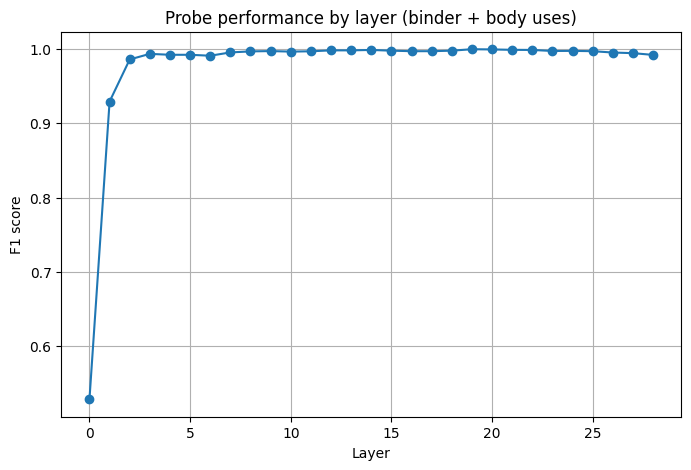

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_df["layer"], results_df["f1"], marker="o")
plt.xlabel("Layer")
plt.ylabel("F1 score")
plt.title("Probe performance by layer (binder + body uses)")
plt.grid(True)
plt.show()

In [136]:
def inspect_probe_on_snippet(code, layer_idx, probe):
    X_snip, y_true, tokens, offsets = build_token_level_data_for_snippet(code, layer_idx=layer_idx)
    y_pred = probe.predict(X_snip.numpy())

    for tok, off, yt, yp in zip(tokens, offsets, y_true.tolist(), y_pred.tolist()):
        print(f"{repr(tok):20} {off}  true={yt}  pred={yp}")

In [137]:
inspect_probe_on_snippet(df.loc[0, "code"], layer_idx=8, probe=probe)

'stash'              (0, 5)  true=0  pred=0
'_sn'                (5, 8)  true=0  pred=0
'ark'                (8, 11)  true=0  pred=0
'y'                  (11, 12)  true=0  pred=0
'_c'                 (12, 14)  true=0  pred=0
'actus'              (14, 19)  true=0  pred=0
'_'                  (19, 20)  true=0  pred=0
'2'                  (20, 21)  true=0  pred=0
'3'                  (21, 22)  true=0  pred=1
'9'                  (22, 23)  true=0  pred=1
' ='                 (23, 25)  true=0  pred=0
' '                  (25, 26)  true=0  pred=0
'0'                  (26, 27)  true=0  pred=0
'\n'                 (27, 28)  true=0  pred=0
'b'                  (28, 29)  true=0  pred=0
'ump'                (29, 32)  true=0  pred=0
'_sp'                (32, 35)  true=0  pred=0
'icy'                (35, 38)  true=0  pred=0
'_widget'            (38, 45)  true=0  pred=0
'_'                  (45, 46)  true=0  pred=1
'7'                  (46, 47)  true=0  pred=0
'0'                  (47, 48)  true=0  

<h1>Java Iterator Probe (XLCoST)</h1>

In [ ]:
# Install javalang if needed
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'javalang', '-q'])

import javalang, re

def load_xlcost_java(split='train', limit=None):
    path = f"{DATA_DIR}/Java/{split}.jsonl"
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            rec = json.loads(line)
            code = xlcost_tokens_to_code(rec['docstring_tokens'])
            try:
                javalang.parse.parse(code)
                rows.append({'code': code, 'language': 'Java', 'split': split})
            except Exception:
                continue
    return pd.DataFrame(rows)

df_java = load_xlcost_java(split='train', limit=3000)
print(f'Loaded {len(df_java)} valid Java programs from XLCoST program-level')
print(df_java.head())


In [ ]:
def find_java_iterator_spans(code):
    def line_col_to_offset(c, line, col):
        lines_list = c.splitlines(keepends=True)
        return sum(len(lines_list[i]) for i in range(line - 1)) + col

    def collect_refs(node, var_name, results):
        if node is None:
            return
        if isinstance(node, javalang.tree.MemberReference):
            if node.member == var_name and not node.qualifier:
                if node.position:
                    results.append(node.position)
        for child in (node.children or []):
            if isinstance(child, list):
                for item in child:
                    if isinstance(item, javalang.tree.Node):
                        collect_refs(item, var_name, results)
            elif isinstance(child, javalang.tree.Node):
                collect_refs(child, var_name, results)

    try:
        tree = javalang.parse.parse(code)
    except Exception:
        return []

    spans = []
    for path, node in tree:
        if not isinstance(node, javalang.tree.EnhancedForStatement):
            continue
        var_name = node.var.name

        # Binder: FormalParameter position may land on the type, scan forward for the name
        if node.var.position:
            p = node.var.position
            start = line_col_to_offset(code, p.line, p.column - 1)
            m = re.search(r'\b' + re.escape(var_name) + r'\b', code[start:])
            if m:
                spans.append((start + m.start(), start + m.end()))

        # Body uses
        body_positions = []
        body = node.body if isinstance(node.body, list) else [node.body]
        for stmt in body:
            if isinstance(stmt, javalang.tree.Node):
                collect_refs(stmt, var_name, body_positions)
        for pos in body_positions:
            s = line_col_to_offset(code, pos.line, pos.column - 1)
            spans.append((s, s + len(var_name)))

    return spans


In [ ]:
def build_java_token_level_data(code, layer_idx):
    spans = find_java_iterator_spans(code)
    enc = tokenizer(
        code,
        return_tensors='pt',
        return_offsets_mapping=True,
        add_special_tokens=False,
        truncation=True,
        max_length=512,
    )
    offset_mapping = enc.pop('offset_mapping')[0].tolist()
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc, output_hidden_states=True)
    hidden = out.hidden_states[layer_idx][0].cpu()
    labels = align_spans_to_tokens(spans, offset_mapping)
    return hidden, torch.tensor(labels)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def collect_java_dataset(df, indices, layer_idx, print_every=20):
    X_list, y_list, skipped = [], [], 0
    for j, idx in enumerate(indices):
        if j % print_every == 0:
            print(f'[layer {layer_idx}] {j}/{len(indices)}')
        try:
            X, y = build_java_token_level_data(df.loc[idx, 'code'], layer_idx)
            if y.sum() == 0:
                skipped += 1
                continue
            X_list.append(X.numpy())
            y_list.append(y.numpy())
        except Exception:
            skipped += 1
    print(f'Skipped {skipped} (no iterator spans or parse error)')
    return np.concatenate(X_list), np.concatenate(y_list)

java_indices = list(range(len(df_java)))
java_train_idx, java_test_idx = train_test_split(java_indices, test_size=0.2, random_state=42)
print('Java train:', len(java_train_idx), '  test:', len(java_test_idx))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

java_layer_results = []
for layer_idx in range(num_layers):
    X_tr, y_tr = collect_java_dataset(df_java, java_train_idx, layer_idx, print_every=100)
    X_te, y_te = collect_java_dataset(df_java, java_test_idx,  layer_idx, print_every=100)
    probe_j = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    probe_j.fit(X_tr, y_tr)
    y_pred = probe_j.predict(X_te)
    java_layer_results.append({
        'layer':     layer_idx,
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
    })
    print(f'Layer {layer_idx:2d} | F1={java_layer_results[-1]["f1"]:.3f}')

java_results_df = pd.DataFrame(java_layer_results)
print(java_results_df)


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df['layer'],      results_df['f1'],      marker='o', label='Python')
ax.plot(java_results_df['layer'], java_results_df['f1'], marker='s', label='Java')
ax.set_xlabel('Layer')
ax.set_ylabel('F1 Score')
ax.set_title('Iterator variable probe F1 by layer — Python vs Java (Qwen2.5-Coder-1.5B)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('iterator_probe_python_vs_java.png', dpi=150)
plt.show()
